## Problem Statement

### Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.). 



## Objective
“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost. 
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description
- The data provided is a transformed version of original data which was collected using sensors.
- Train.csv - To be used for training and tuning of models. 
- Test.csv - To be used only for testing the performance of the final best model.
- Both the datasets consist of 40 predictor variables and 1 target variable

## Importing necessary libraries

In [1]:
# To help with reading and manipulating data
import pandas as pd
import numpy as np

# To help with data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# To be used for missing value imputation
from sklearn.impute import SimpleImputer

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To get different metric scores, and split data
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    plot_confusion_matrix,
)

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To be used for tuning the model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To use statistical functions
import scipy.stats as stats

# To be used for creating pipelines and personalizing them
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

# This will help in making the Python code more structured automatically (good coding practice)
%load_ext nb_black

<IPython.core.display.Javascript object>

## Loading the dataset

In [2]:
# Loading the dataset
train = pd.read_csv("train.csv")

<IPython.core.display.Javascript object>

## Data Overview

### Observations and Sanity Checks


In [3]:
# Creating a copy of original dataset
data_train = train.copy()

<IPython.core.display.Javascript object>

In [4]:
data_train.shape

(20000, 41)

<IPython.core.display.Javascript object>

#### Jonathan's Comments:
- There are 20000 rows and 41 attributes in the dataset

In [5]:
data_train.head(10)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.465,-4.679,3.102,0.506,-0.221,-2.033,-2.911,0.051,-1.522,3.762,-5.715,0.736,0.981,1.418,-3.376,-3.047,0.306,2.914,2.270,4.395,-2.388,0.646,-1.191,3.133,0.665,-2.511,-0.037,0.726,-3.982,-1.073,1.667,3.060,-1.690,2.846,2.235,6.667,0.444,-2.369,2.951,-3.480,0
1,3.366,3.653,0.910,-1.368,0.332,2.359,0.733,-4.332,0.566,-0.101,1.914,-0.951,-1.255,-2.707,0.193,-4.769,-2.205,0.908,0.757,-5.834,-3.065,1.597,-1.757,1.766,-0.267,3.625,1.500,-0.586,0.783,-0.201,0.025,-1.795,3.033,-2.468,1.895,-2.298,-1.731,5.909,-0.386,0.616,0
2,-3.832,-5.824,0.634,-2.419,-1.774,1.017,-2.099,-3.173,-2.082,5.393,-0.771,1.107,1.144,0.943,-3.164,-4.248,-4.039,3.689,3.311,1.059,-2.143,1.650,-1.661,1.680,-0.451,-4.551,3.739,1.134,-2.034,0.841,-1.600,-0.257,0.804,4.086,2.292,5.361,0.352,2.940,3.839,-4.309,0
3,1.618,1.888,7.046,-1.147,0.083,-1.530,0.207,-2.494,0.345,2.119,-3.053,0.460,2.705,-0.636,-0.454,-3.174,-3.404,-1.282,1.582,-1.952,-3.517,-1.206,-5.628,-1.818,2.124,5.295,4.748,-2.309,-3.963,-6.029,4.949,-3.584,-2.577,1.364,0.623,5.550,-1.527,0.139,3.101,-1.277,0
4,-0.111,3.872,-3.758,-2.983,3.793,0.545,0.205,4.849,-1.855,-6.220,1.998,4.724,0.709,-1.989,-2.633,4.184,2.245,3.734,-6.313,-5.380,-0.887,2.062,9.446,4.490,-3.945,4.582,-8.780,-3.383,5.107,6.788,2.044,8.266,6.629,-10.069,1.223,-3.230,1.687,-2.164,-3.645,6.510,0
5,0.160,-4.234,-0.264,-5.477,-0.191,-0.356,-0.134,4.067,-3.859,1.692,0.138,3.975,0.673,1.878,0.764,4.236,-2.129,2.348,-2.147,-0.982,0.386,1.011,3.419,0.996,0.061,-3.037,1.788,-1.727,0.308,1.902,4.666,3.227,0.629,-1.549,1.322,5.461,1.109,-3.870,0.274,2.806,0
6,-0.185,-4.721,0.865,-3.079,-2.227,-1.282,-0.805,3.290,-1.568,0.750,0.529,3.221,2.945,1.724,-0.923,2.535,-1.697,0.677,-0.246,2.748,-1.165,0.248,1.161,-2.850,0.503,-3.532,1.861,-1.465,0.874,2.418,0.939,-0.545,-0.763,0.816,1.889,3.624,1.556,-5.433,0.679,0.465,0
7,1.735,1.683,-1.269,4.601,-1.417,-2.544,0.132,-0.199,3.094,-1.109,-1.662,0.944,3.481,0.137,-3.473,-4.076,1.727,-1.909,3.569,2.512,-4.579,3.063,3.686,0.611,-0.430,0.880,-0.994,1.134,-3.768,-0.692,-5.244,1.717,-3.839,1.569,1.795,-4.269,-0.516,-0.619,-0.831,-4.967,1
8,1.782,1.315,4.249,-0.518,-0.149,0.033,-1.088,-3.118,0.625,1.567,-0.415,-1.401,2.607,-1.024,-2.878,-4.524,-4.354,0.107,1.299,-3.596,-5.409,0.633,-3.043,0.965,-0.266,4.671,1.847,-2.321,-1.318,-0.682,3.281,1.611,2.951,-1.862,4.390,1.371,-2.516,0.770,0.831,-2.311,0
9,-0.894,4.011,5.252,3.321,0.727,-4.771,1.031,3.632,-1.391,-1.967,-4.779,6.617,-0.148,-2.513,0.734,0.475,5.085,-2.361,4.561,2.287,-2.307,-0.949,-0.301,2.546,0.738,4.266,-4.145,-0.013,-1.469,-2.003,1.680,-0.636,-4.449,2.296,1.575,1.376,0.597,-1.414,0.544,0.035,0


<IPython.core.display.Javascript object>

In [6]:
data_train.tail(10)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
19990,-0.580,-2.630,0.474,-2.671,-2.324,-1.830,-0.112,3.581,-1.085,-1.369,1.767,6.225,5.042,0.401,-2.542,2.450,-1.429,0.166,0.522,2.209,-2.434,0.557,2.735,-3.877,-0.718,-1.494,0.256,-2.087,1.982,3.623,-1.735,-1.940,-0.769,0.802,1.815,1.657,2.425,-4.565,0.827,0.229,0
19991,6.826,3.142,6.575,-4.685,-1.979,1.553,1.268,-5.975,0.297,2.048,1.804,1.135,1.669,-3.104,0.619,-7.284,-6.666,-0.156,3.029,-7.245,-7.166,1.511,-6.424,-2.026,2.080,5.324,8.180,-2.789,-0.921,-3.272,2.876,-7.818,0.765,-0.539,4.031,2.270,-2.455,5.461,2.018,0.082,0
19992,-0.730,-8.463,1.112,-8.919,-2.309,2.903,-4.203,-3.019,-0.094,2.473,0.469,-1.063,5.314,2.043,-6.506,-5.233,-6.589,8.245,-5.012,0.659,-5.277,2.837,-0.948,-4.253,0.860,-4.562,5.660,-3.459,0.612,3.127,0.417,-2.711,3.625,-3.265,2.393,7.795,2.312,-3.950,3.226,1.138,0
19993,0.251,-5.069,5.866,-5.049,-1.226,-2.078,-3.639,0.941,0.852,0.056,-5.855,1.205,5.854,1.681,-5.514,-4.292,-0.951,5.339,-3.948,4.647,-6.620,1.576,-1.266,-4.026,3.238,-0.598,2.816,-3.942,-2.896,-1.506,3.624,-2.642,-2.768,-2.612,1.854,9.388,2.557,-9.390,2.846,1.878,0
19994,-2.547,-2.370,-0.729,-0.948,1.418,-2.490,-0.821,4.790,-2.949,0.209,-4.885,4.838,-0.586,1.126,-1.009,1.744,3.863,3.288,-0.641,2.604,-0.275,2.110,5.816,5.163,-0.078,-2.389,-3.368,0.463,-2.438,0.592,2.048,5.798,-2.451,-0.697,0.461,4.299,1.974,-3.614,0.165,1.343,0
19995,-2.071,-1.088,-0.796,-3.012,-2.288,2.807,0.481,0.105,-0.587,-2.899,8.868,1.717,1.358,-1.777,0.710,4.945,-3.100,-1.199,-1.085,-0.365,3.131,-3.948,-3.578,-8.139,-1.937,-1.328,-0.403,-1.735,9.996,6.955,-3.938,-8.274,5.745,0.589,-0.650,-3.043,2.216,0.609,0.178,2.928,1
19996,2.890,2.483,5.644,0.937,-1.381,0.412,-1.593,-5.762,2.150,0.272,-2.095,-1.526,0.072,-3.540,-2.762,-10.632,-0.495,1.720,3.872,-1.210,-8.222,2.121,-5.492,1.452,1.450,3.685,1.077,-0.384,-0.839,-0.748,-1.089,-4.159,1.181,-0.742,5.369,-0.693,-1.669,3.660,0.820,-1.987,0
19997,-3.897,-3.942,-0.351,-2.417,1.108,-1.528,-3.520,2.055,-0.234,-0.358,-3.782,2.180,6.112,1.985,-8.330,-1.639,-0.915,5.672,-3.924,2.133,-4.502,2.777,5.728,1.620,-1.700,-0.042,-2.923,-2.760,-2.254,2.552,0.982,7.112,1.476,-3.954,1.856,5.029,2.083,-6.409,1.477,-0.874,0
19998,-3.187,-10.052,5.696,-4.370,-5.355,-1.873,-3.947,0.679,-2.389,5.457,1.583,3.571,9.227,2.554,-7.039,-0.994,-9.665,1.155,3.877,3.524,-7.015,-0.132,-3.446,-4.801,-0.876,-3.812,5.422,-3.732,0.609,5.256,1.915,0.403,3.164,3.752,8.530,8.451,0.204,-7.130,4.249,-6.112,0
19999,-2.687,1.961,6.137,2.600,2.657,-4.291,-2.344,0.974,-1.027,0.497,-9.589,3.177,1.055,-1.416,-4.669,-5.405,3.720,2.893,2.329,1.458,-6.429,1.818,0.806,7.786,0.331,5.257,-4.867,-0.819,-5.667,-2.861,4.674,6.621,-1.989,-1.349,3.952,5.450,-0.455,-2.202,1.678,-1.974,0


<IPython.core.display.Javascript object>

#### Jonathan's Comments:
- There is nothing strange or take care until now
- The attributes are not quite descriptive this not allow perform feature engineering or outliers treatment 

In [7]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

<IPython.core.display.Javascript object>

#### Jonathan's Comments:
- All attributes are float except the target, variable, transformation will be done in  a next step
- Some missing values detected on V1 and V2 variables

In [8]:
round(data_train.isnull().sum() / data_train.isnull().count() * 100, 2)

V1       0.090
V2       0.090
V3       0.000
V4       0.000
V5       0.000
V6       0.000
V7       0.000
V8       0.000
V9       0.000
V10      0.000
V11      0.000
V12      0.000
V13      0.000
V14      0.000
V15      0.000
V16      0.000
V17      0.000
V18      0.000
V19      0.000
V20      0.000
V21      0.000
V22      0.000
V23      0.000
V24      0.000
V25      0.000
V26      0.000
V27      0.000
V28      0.000
V29      0.000
V30      0.000
V31      0.000
V32      0.000
V33      0.000
V34      0.000
V35      0.000
V36      0.000
V37      0.000
V38      0.000
V39      0.000
V40      0.000
Target   0.000
dtype: float64

<IPython.core.display.Javascript object>

#### Jonathan's Comments:
- Missing values on V1 and V2 attributes represents 0.09%

In [9]:
data_train.duplicated().sum()

0

<IPython.core.display.Javascript object>

In [10]:
data_train.nunique()

V1        19982
V2        19982
V3        20000
V4        20000
V5        20000
V6        20000
V7        20000
V8        20000
V9        20000
V10       20000
V11       20000
V12       20000
V13       20000
V14       20000
V15       20000
V16       20000
V17       20000
V18       20000
V19       20000
V20       20000
V21       20000
V22       20000
V23       20000
V24       20000
V25       20000
V26       20000
V27       20000
V28       20000
V29       20000
V30       20000
V31       20000
V32       20000
V33       20000
V34       20000
V35       20000
V36       20000
V37       20000
V38       20000
V39       20000
V40       20000
Target        2
dtype: int64

<IPython.core.display.Javascript object>

#### Jonathan's Comments:
- There is not duplicated data 

In [11]:
data_train.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,19982.000,19982.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,-0.272,0.440,2.485,-0.083,-0.054,-0.995,-0.879,-0.548,-0.017,-0.013,-1.895,1.605,1.580,-0.951,-2.415,-2.925,-0.134,1.189,1.182,0.024,-3.611,0.952,-0.366,1.134,-0.002,1.874,-0.612,-0.883,-0.986,-0.016,0.487,0.304,0.050,-0.463,2.230,1.515,0.011,-0.344,0.891,-0.876,0.056
std,3.442,3.151,3.389,3.432,2.105,2.041,1.762,3.296,2.161,2.193,3.124,2.930,2.875,1.790,3.355,4.222,3.345,2.592,3.397,3.669,3.568,1.652,4.032,3.912,2.017,3.435,4.369,1.918,2.684,3.005,3.461,5.500,3.575,3.184,2.937,3.801,1.788,3.948,1.753,3.012,0.229
min,-11.876,-12.320,-10.708,-15.082,-8.603,-10.227,-7.950,-15.658,-8.596,-9.854,-14.832,-12.948,-13.228,-7.739,-16.417,-20.374,-14.091,-11.644,-13.492,-13.923,-17.956,-10.122,-14.866,-16.387,-8.228,-11.834,-14.905,-9.269,-12.579,-14.796,-13.723,-19.877,-16.898,-17.985,-15.350,-14.833,-5.478,-17.375,-6.439,-11.024,0.000
25%,-2.737,-1.641,0.207,-2.348,-1.536,-2.347,-2.031,-2.643,-1.495,-1.411,-3.922,-0.397,-0.224,-2.171,-4.415,-5.634,-2.216,-0.404,-1.050,-2.433,-5.930,-0.118,-3.099,-1.468,-1.365,-0.338,-3.652,-2.171,-2.787,-1.867,-1.818,-3.420,-2.243,-2.137,0.336,-0.944,-1.256,-2.988,-0.272,-2.940,0.000
50%,-0.748,0.472,2.256,-0.135,-0.102,-1.001,-0.917,-0.389,-0.068,0.101,-1.921,1.508,1.637,-0.957,-2.383,-2.683,-0.015,0.883,1.279,0.033,-3.533,0.975,-0.262,0.969,0.025,1.951,-0.885,-0.891,-1.176,0.184,0.490,0.052,-0.066,-0.255,2.099,1.567,-0.128,-0.317,0.919,-0.921,0.000
75%,1.840,2.544,4.566,2.131,1.340,0.380,0.224,1.723,1.409,1.477,0.119,3.571,3.460,0.271,-0.359,-0.095,2.069,2.572,3.493,2.512,-1.266,2.026,2.452,3.546,1.397,4.130,2.189,0.376,0.630,2.036,2.731,3.762,2.255,1.437,4.064,3.984,1.176,2.279,2.058,1.120,0.000
max,15.493,13.089,17.091,13.236,8.134,6.976,8.006,11.679,8.138,8.108,11.826,15.081,15.420,5.671,12.246,13.583,16.756,13.180,13.238,16.052,13.840,7.410,14.459,17.163,8.223,16.836,17.560,6.528,10.722,12.506,17.255,23.633,16.692,14.358,15.291,19.330,7.467,15.290,7.760,10.654,1.000


<IPython.core.display.Javascript object>

## Exploratory Data Analysis (EDA)

### Plotting histograms and boxplots for all the variables

In [12]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

<IPython.core.display.Javascript object>

In [13]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

<IPython.core.display.Javascript object>

In [14]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

<IPython.core.display.Javascript object>

## Univariate analysis

### Plotting all the features at one go

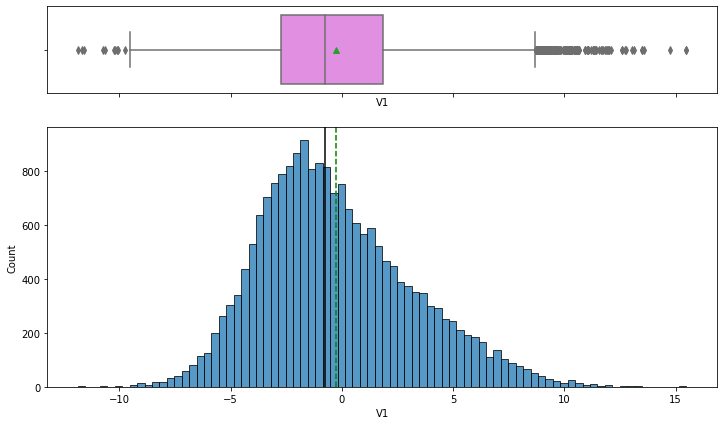

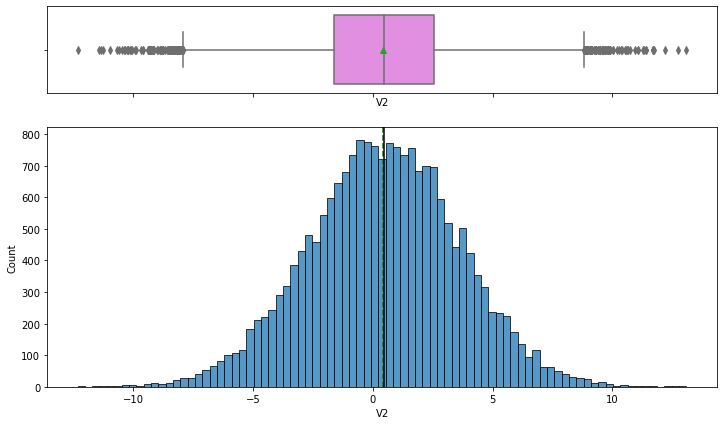

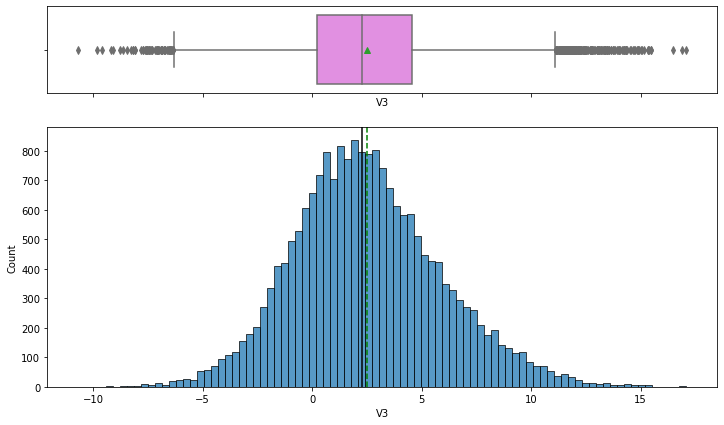

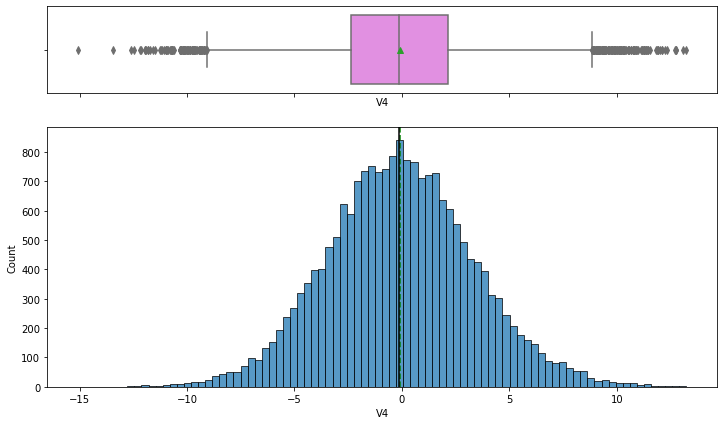

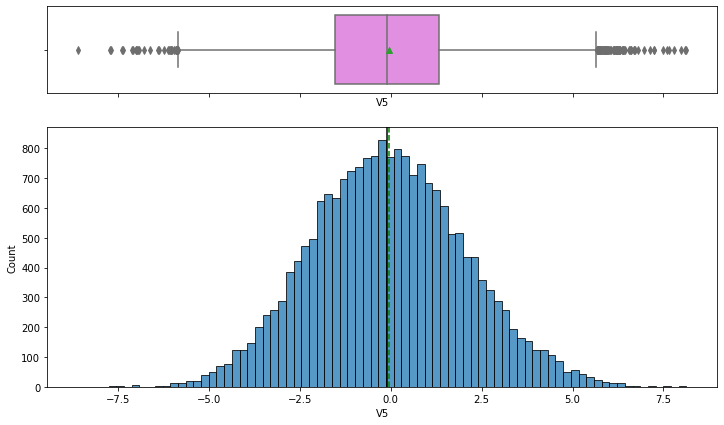

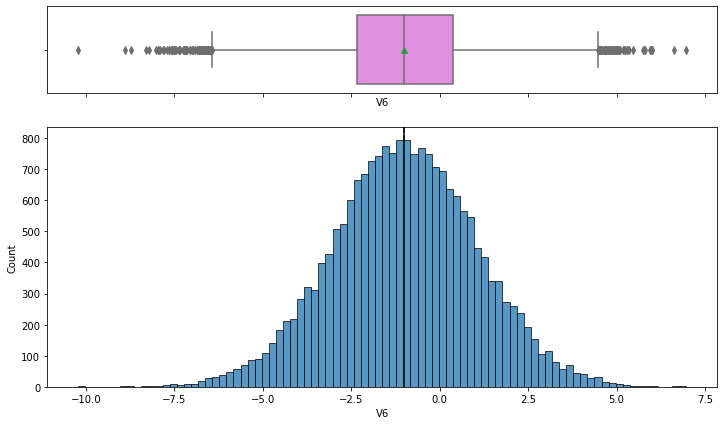

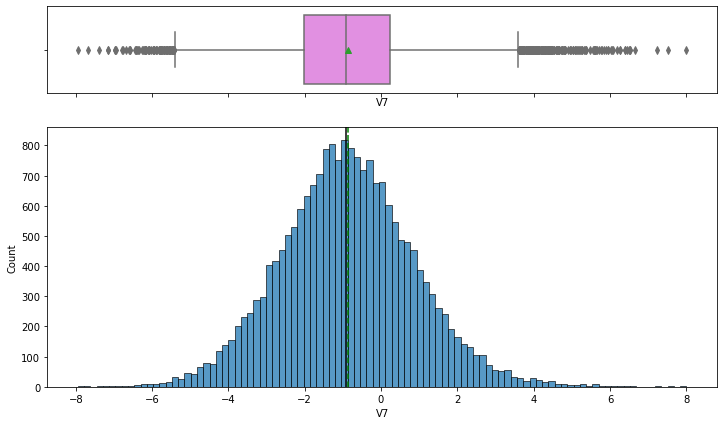

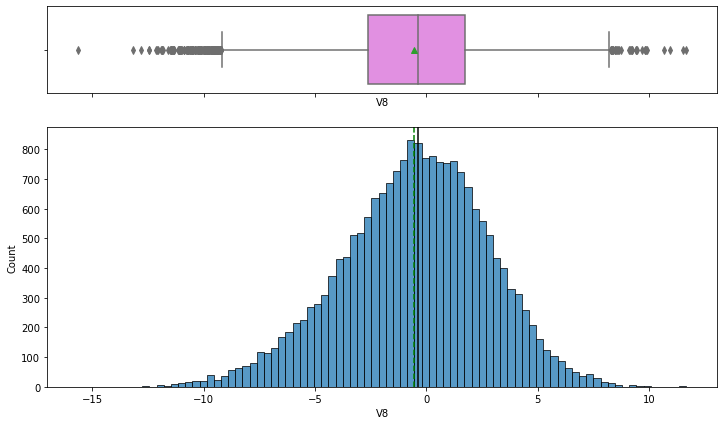

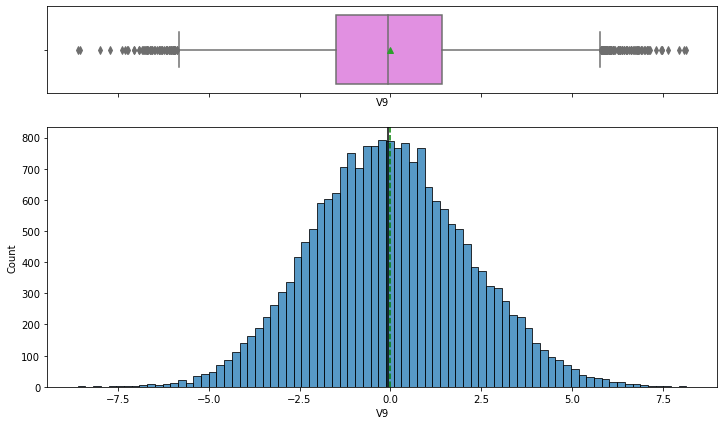

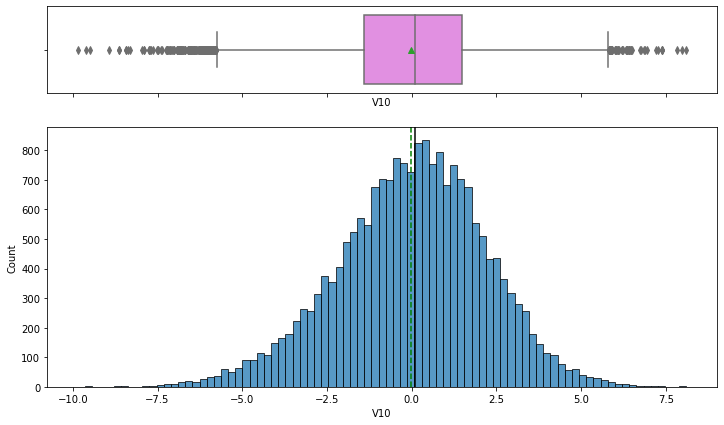

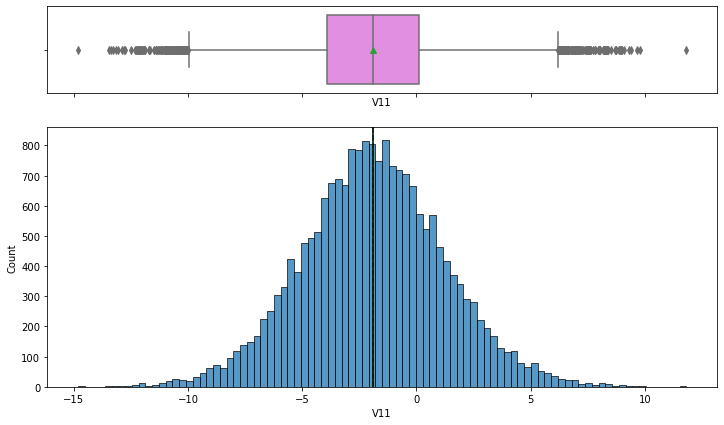

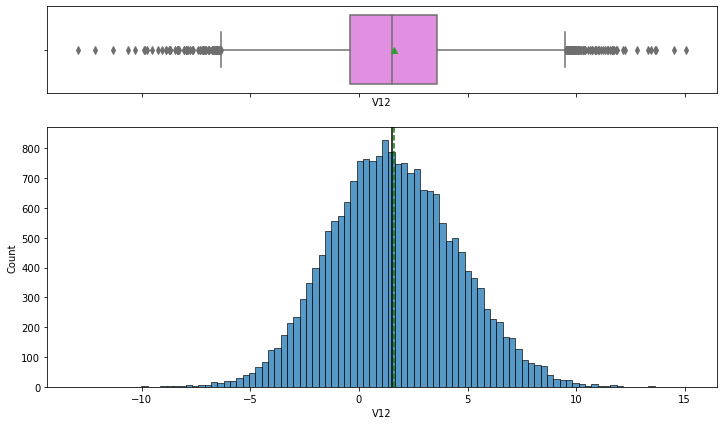

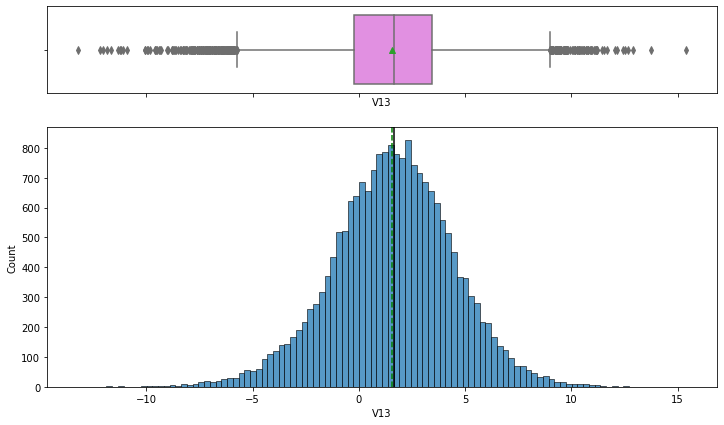

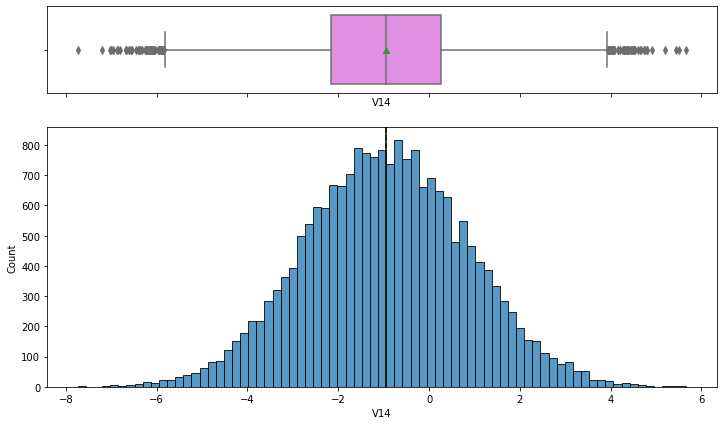

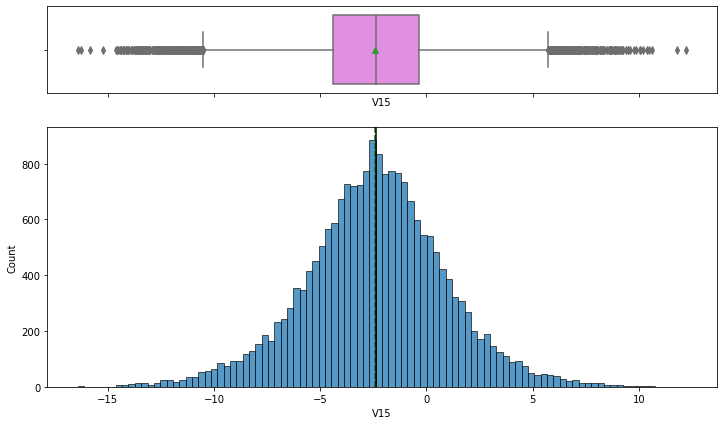

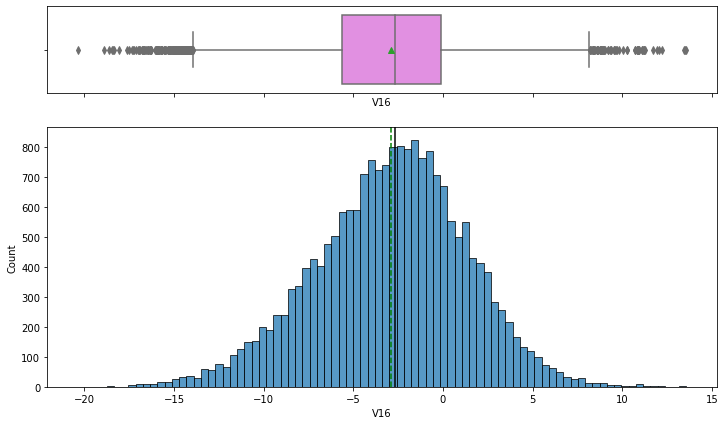

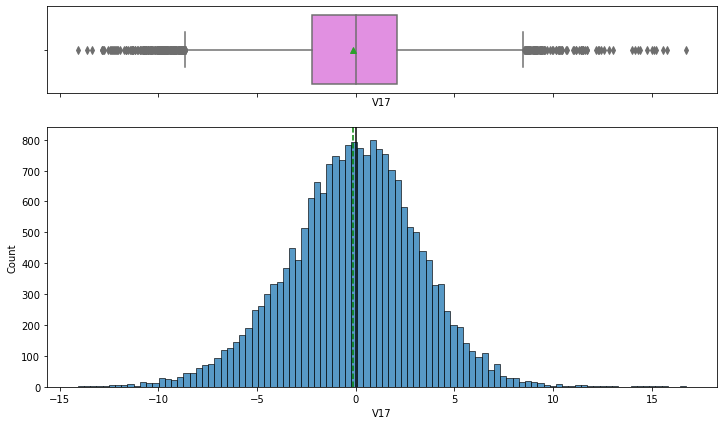

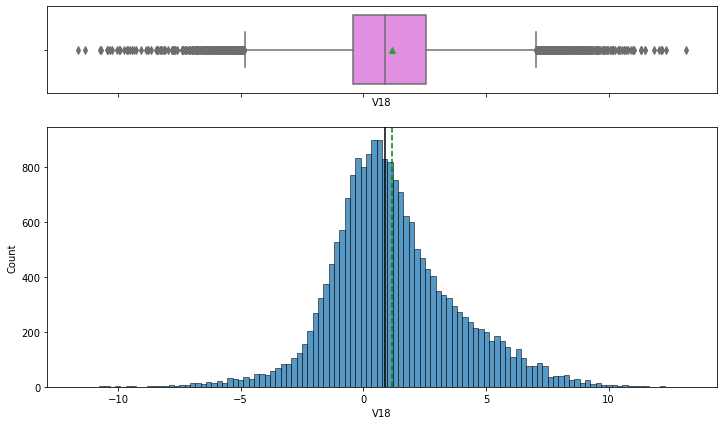

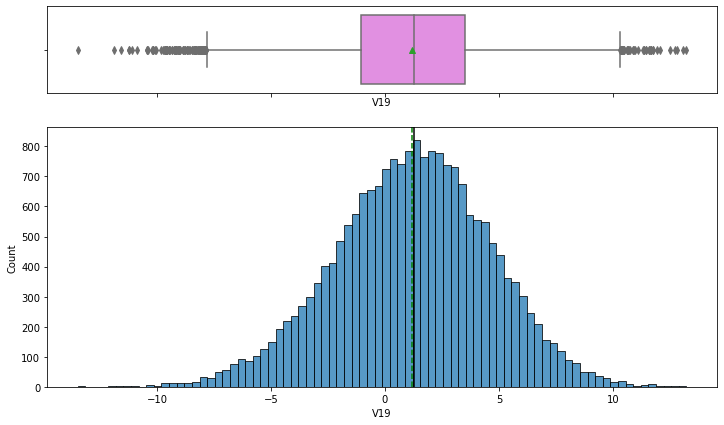

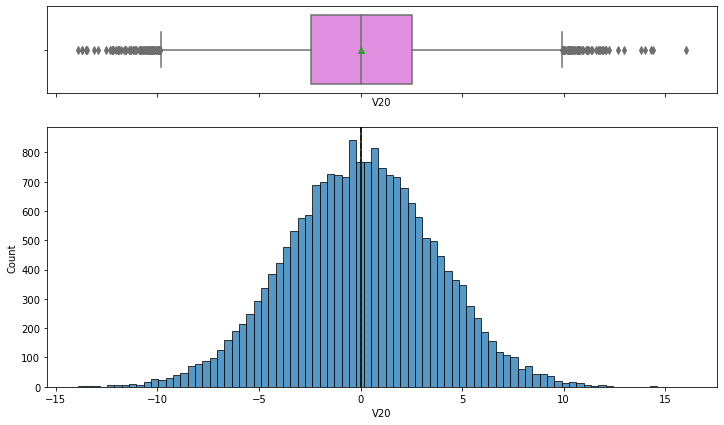

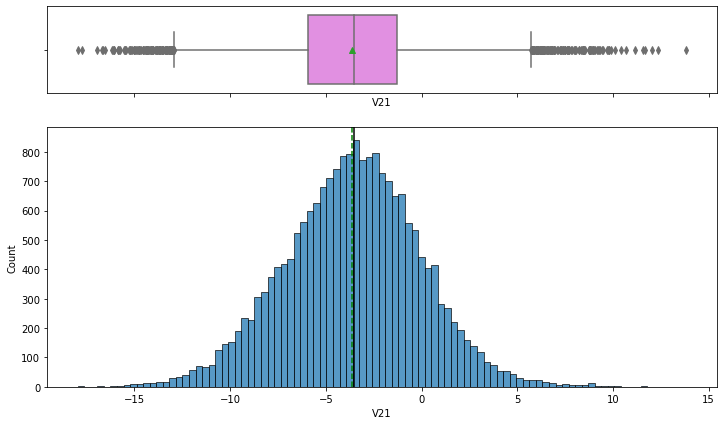

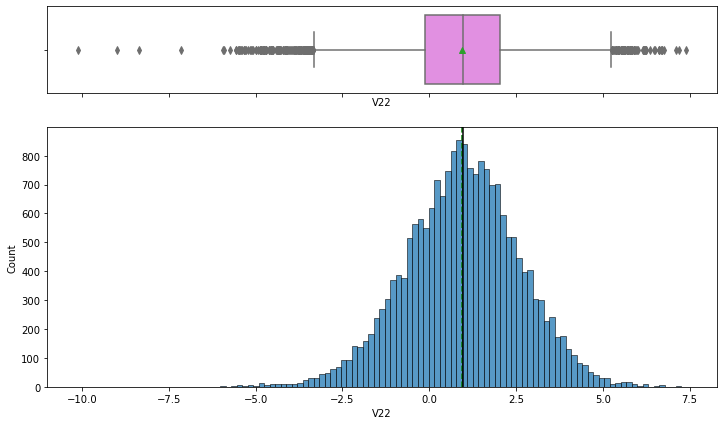

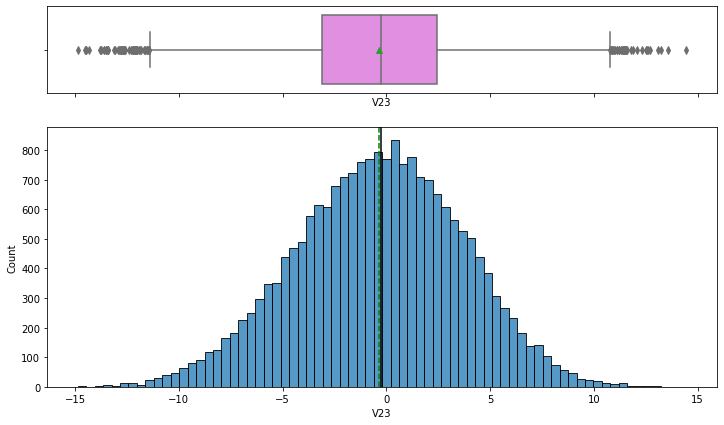

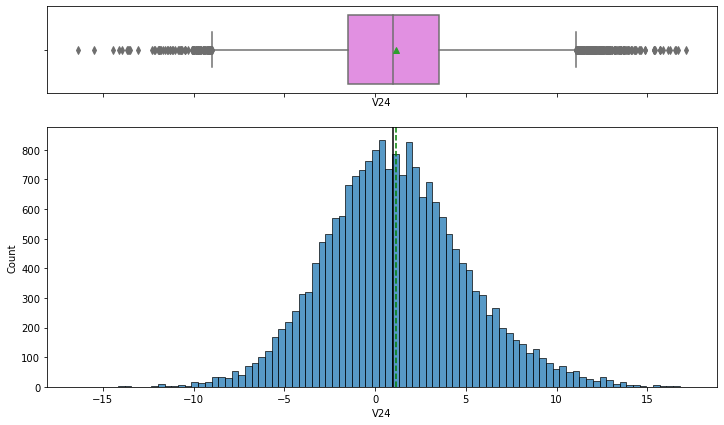

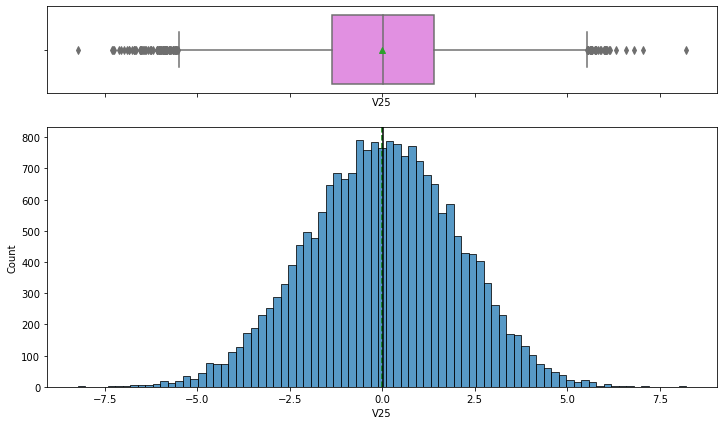

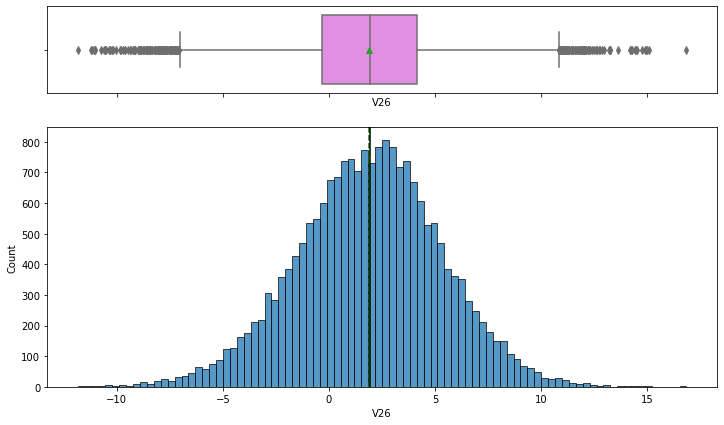

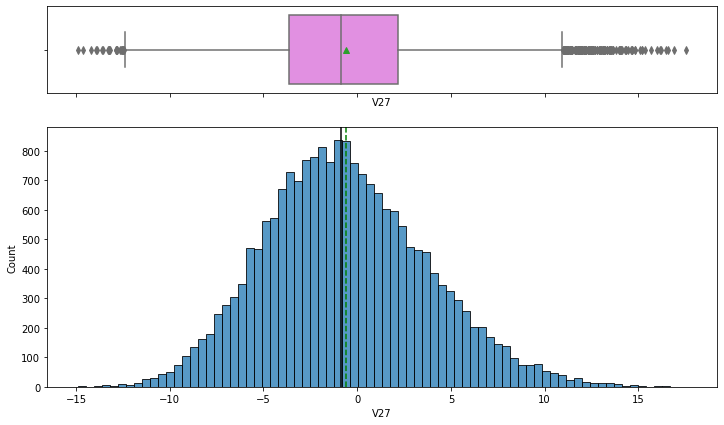

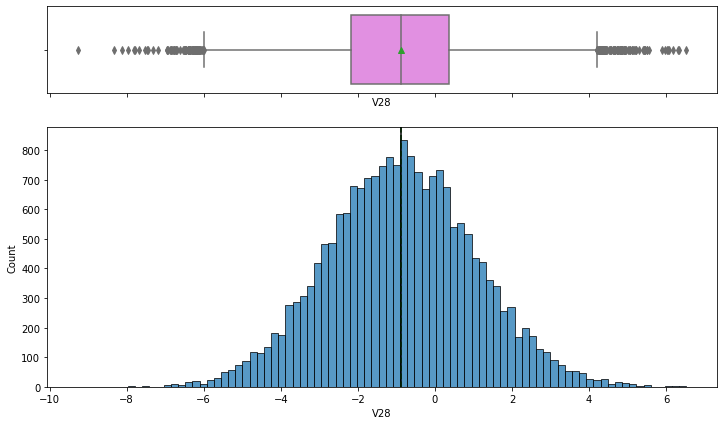

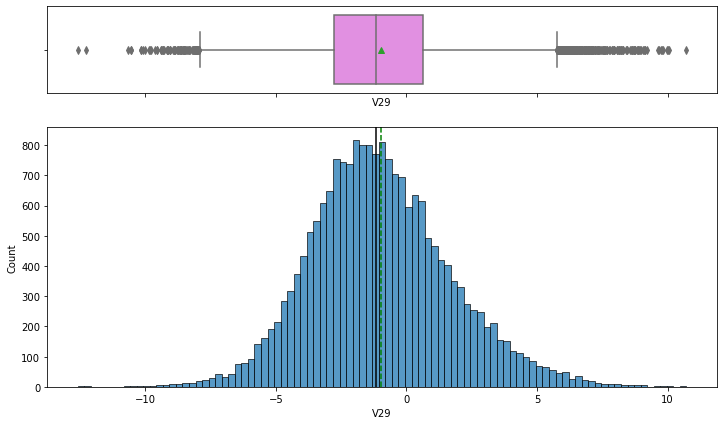

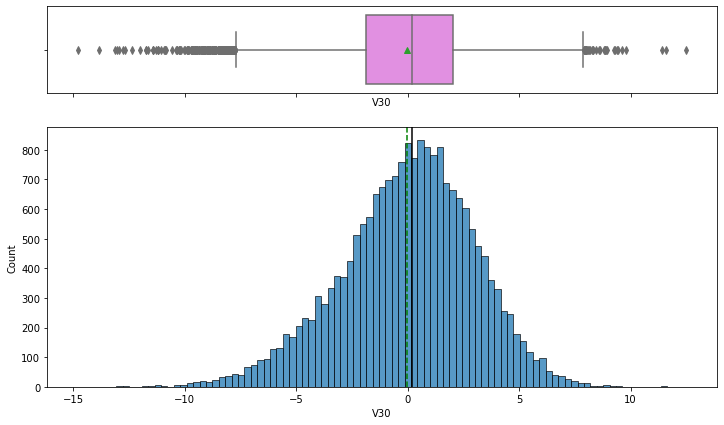

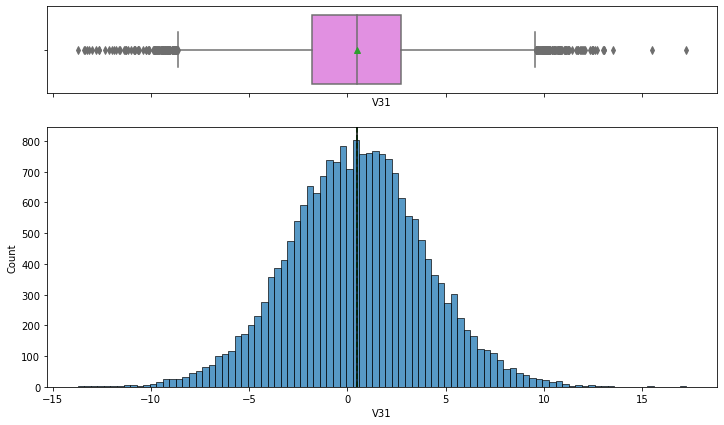

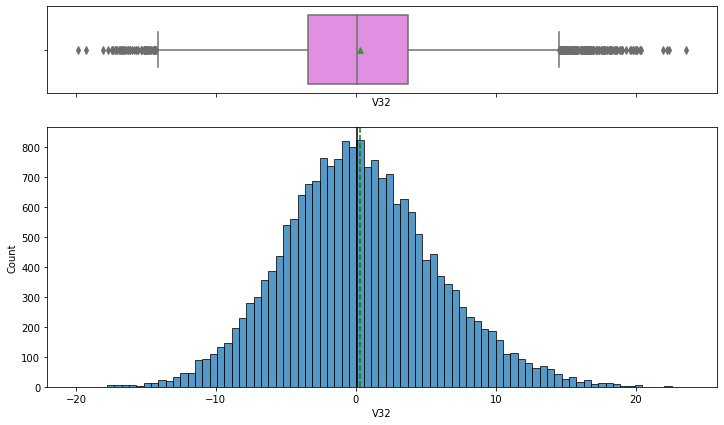

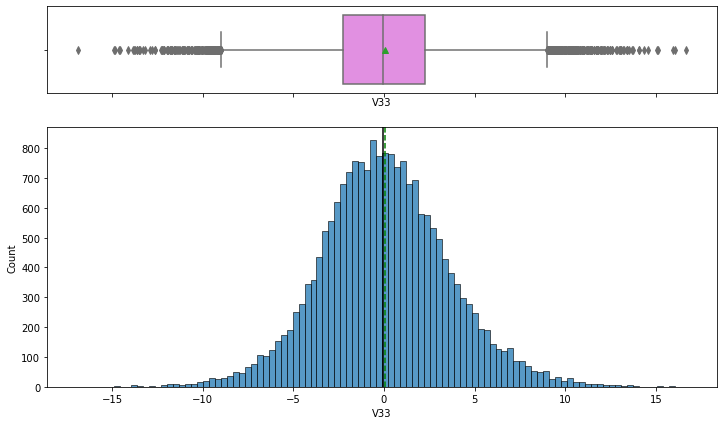

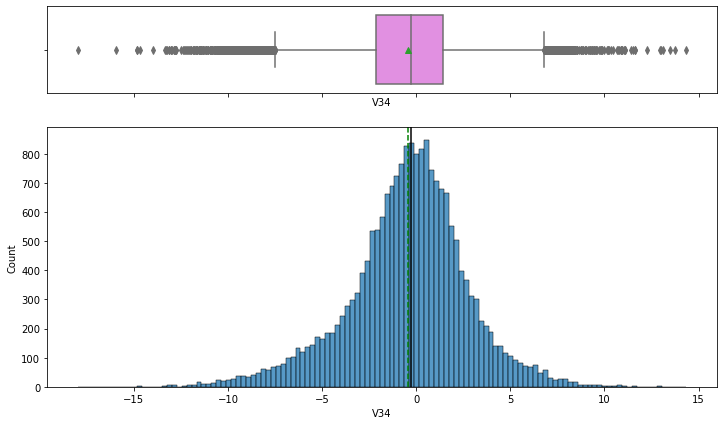

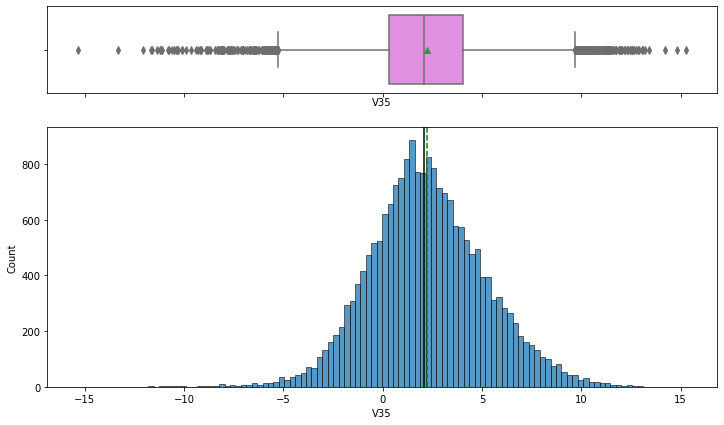

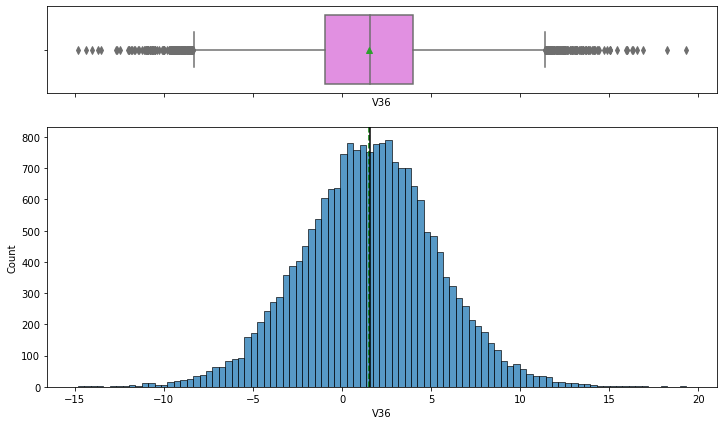

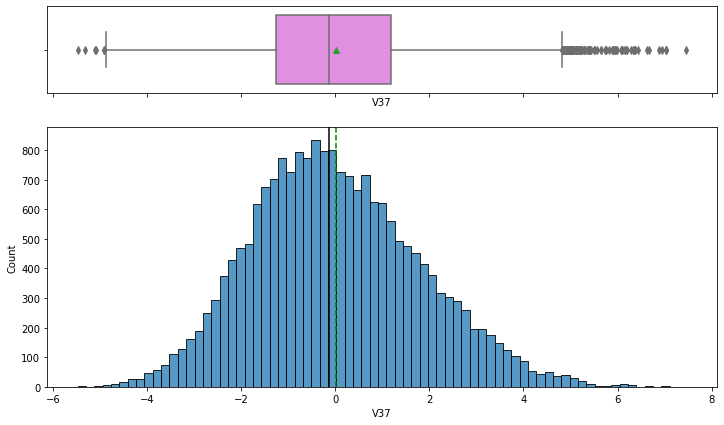

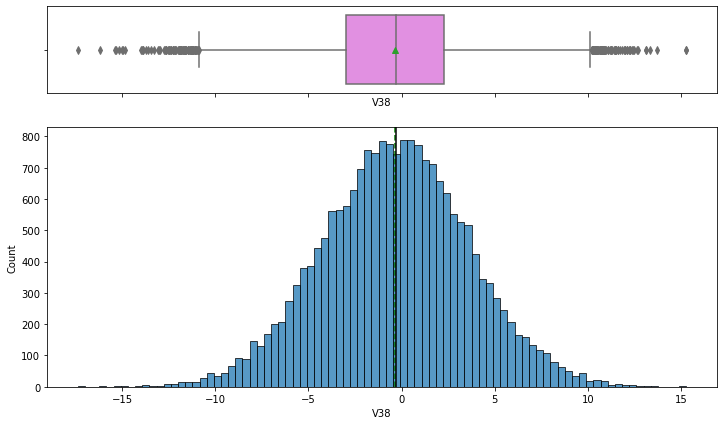

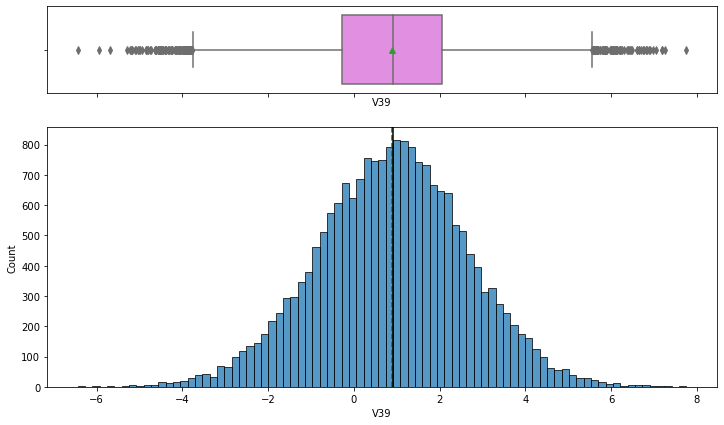

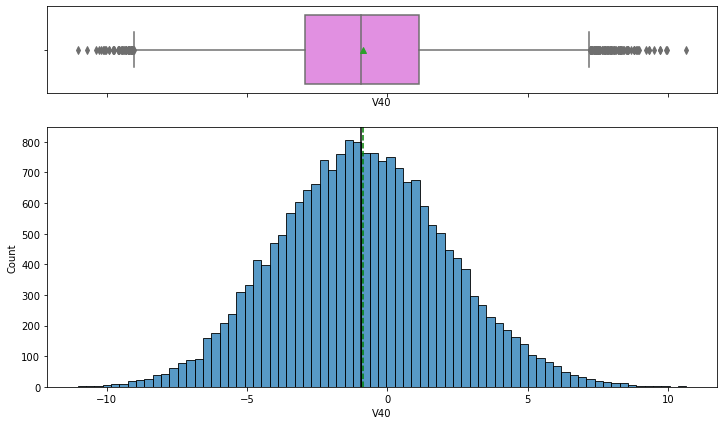

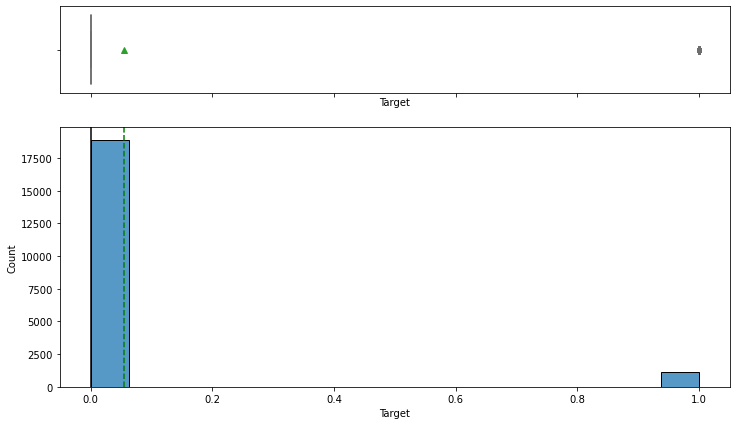

<IPython.core.display.Javascript object>

In [15]:
for feature in data_train.columns:
    histogram_boxplot(
        data_train, feature, figsize=(12, 7), kde=False, bins=None
    )  ## Please change the dataframe name as you define while reading the data

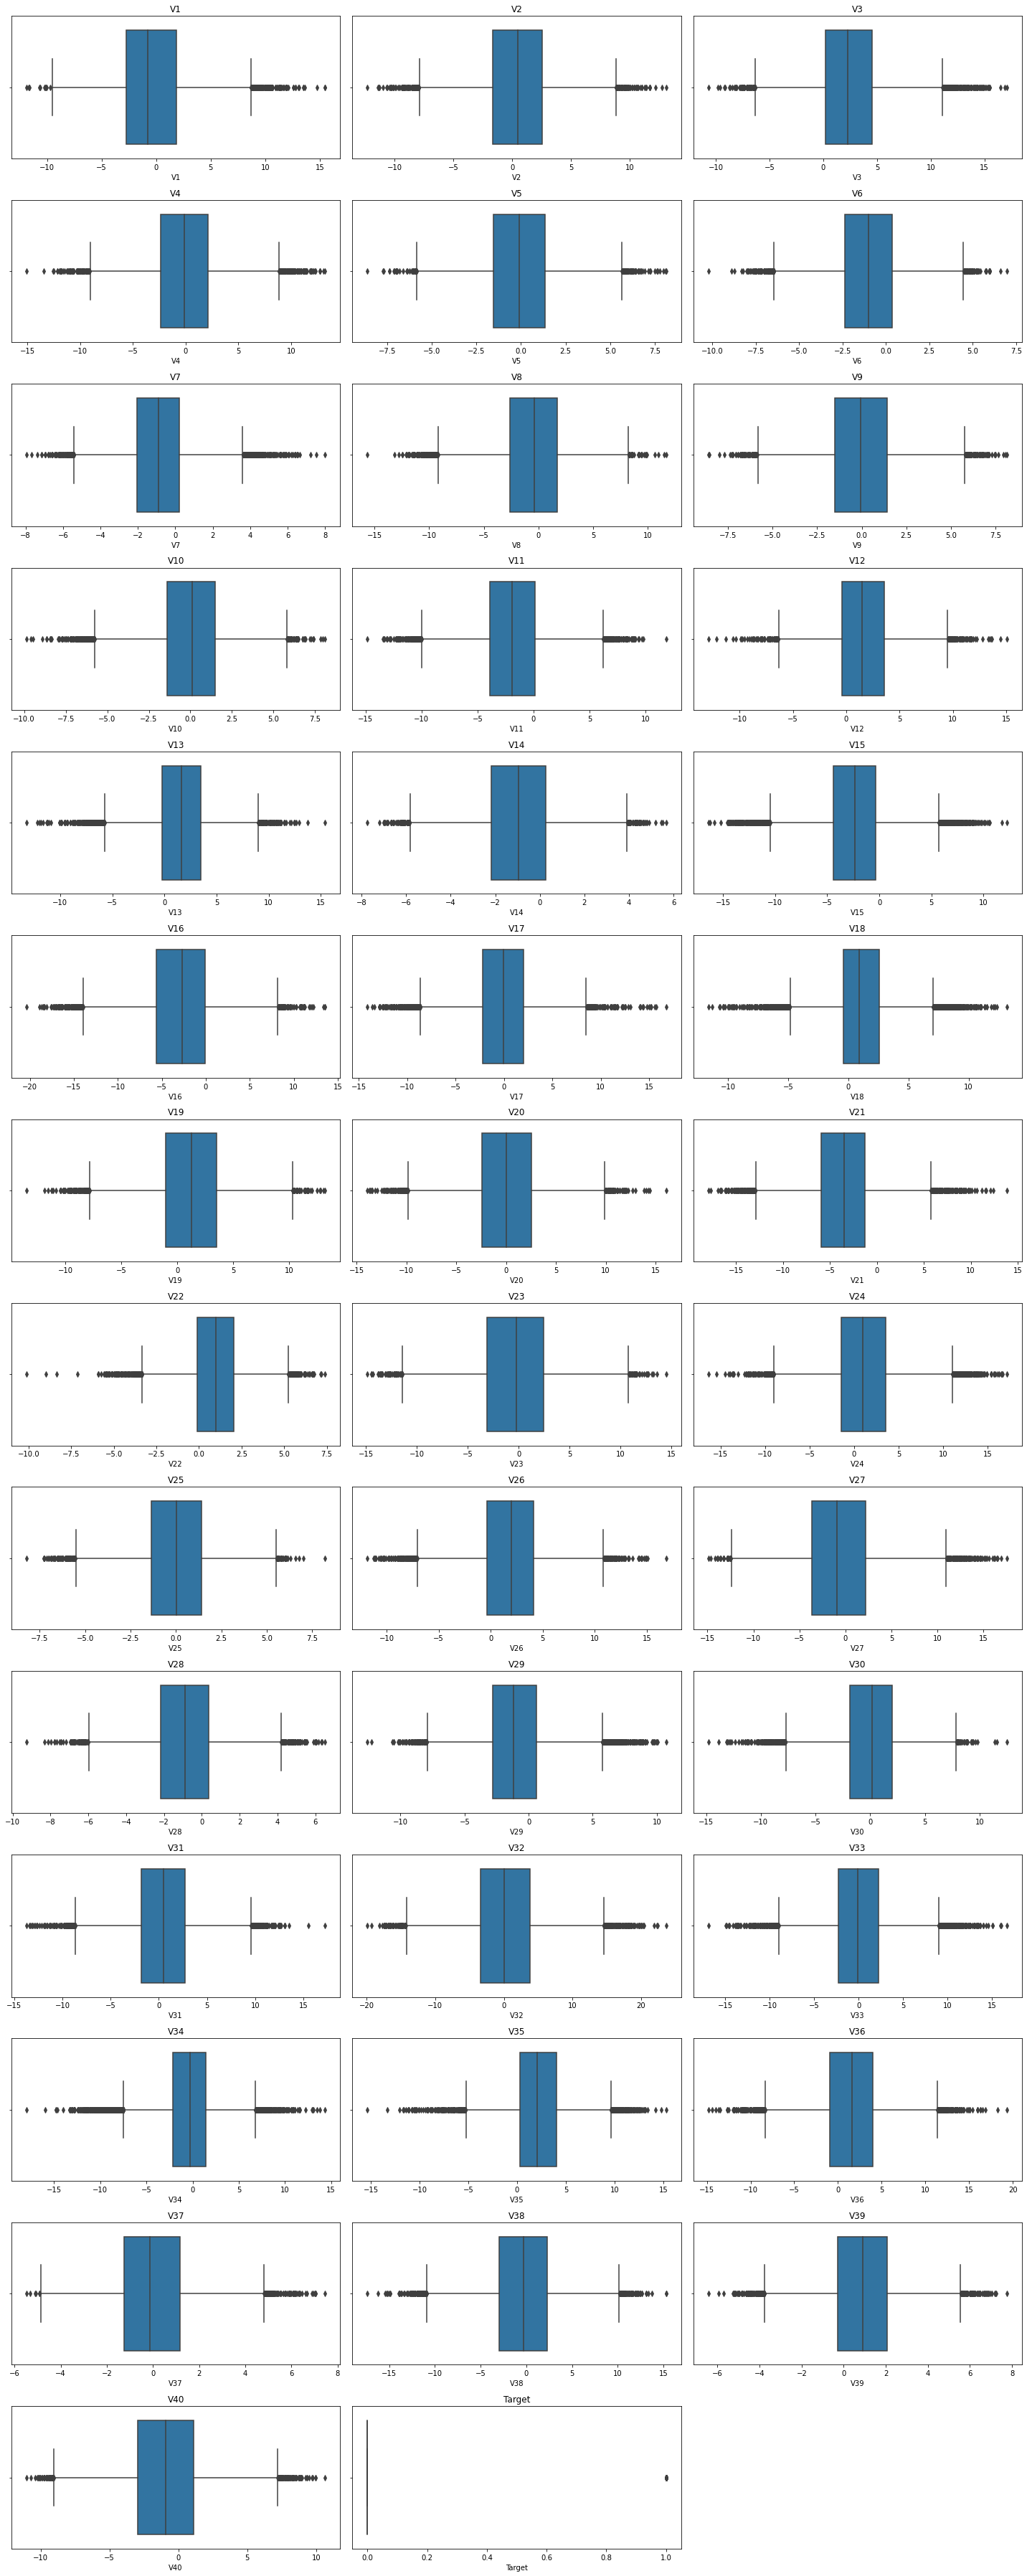

<IPython.core.display.Javascript object>

In [16]:
cols = data_train.columns.tolist()

plt.figure(figsize=(20, 50))
for i, variable in enumerate(cols):
    plt.subplot(14, 3, i + 1)
    sns.boxplot(data_train[variable])
    plt.tight_layout()
    plt.title(variable)
plt.show()

#### Jonathan's Comments:
- There is outliers present on all variables but as was mentioned before the lack of description for variables don't allow check if a really outliers, so let's assume that are real and correct data

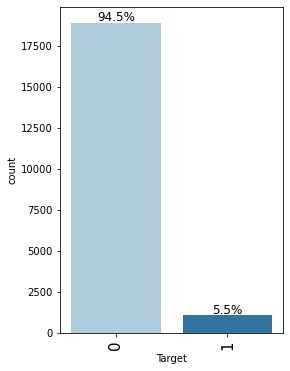

<IPython.core.display.Javascript object>

In [17]:
labeled_barplot(data_train, "Target", perc=True)

#### Jonathan's Comments:
- The target is "imbalanced"
- The majority class is "No failure" with a 94.5%

## Data Pre-processing

In [18]:
# Split data
data1 = data_train.copy()

X = data1.drop(["Target"], axis=1)
Y = data1["Target"]

<IPython.core.display.Javascript object>

In [19]:
# Splitting data into training and validation sets:

X_train, X_val, y_train, y_val = train_test_split(
    X, Y, test_size=0.30, random_state=1, stratify=Y
)
print(X_train.shape, X_val.shape)

(14000, 40) (6000, 40)


<IPython.core.display.Javascript object>

#### Jonathan's Comments:
- The row number for sets are:
    - Train: 14000
    - Validation: 6000    

In [20]:
print("Counts on Train set for target variable:")
y_train.value_counts()

Counts on Train set for target variable:


0    13223
1      777
Name: Target, dtype: int64

<IPython.core.display.Javascript object>

In [21]:
print("Proportion on Train set for target variable:")
(y_train.value_counts() / y_train.count()) * 100

Proportion on Train set for target variable:


0   94.450
1    5.550
Name: Target, dtype: float64

<IPython.core.display.Javascript object>

In [22]:
print("Counts on Validation set for target variable:")
y_val.value_counts()

Counts on Validation set for target variable:


0    5667
1     333
Name: Target, dtype: int64

<IPython.core.display.Javascript object>

In [23]:
print("Proportion on Validation set for target variable:")
(y_val.value_counts() / y_val.count()) * 100

Proportion on Validation set for target variable:


0   94.450
1    5.550
Name: Target, dtype: float64

<IPython.core.display.Javascript object>

#### Jonathan's Comments:

After split the proportion is kept for both train and validation sets

## Missing value imputation




In [24]:
imputer = SimpleImputer(strategy="median")
impute = imputer.fit(X_train)

X_train = pd.DataFrame(impute.transform(X_train), columns=X_train.columns)
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_train.columns)

<IPython.core.display.Javascript object>

In [25]:
# Checking that no column has missing values in train or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)

V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------


<IPython.core.display.Javascript object>

#### Jonathan's Comments:

Missing values has been treated

## Model Building

### Model evaluation criterion

The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model.
- False negatives (FN) are real failures in a generator where there is no detection by model. 
- False positives (FP) are failure detections in a generator where there is no failure.

**Which metric to optimize?**

* We need to choose the metric which will ensure that the maximum number of generator failures are predicted correctly by the model.
* We would want Recall to be maximized as greater the Recall, the higher the chances of minimizing false negatives.
* We want to minimize false negatives because if a model predicts that a machine will have no failure when there will be a failure, it will increase the maintenance cost.

**Let's define a function to output different metrics (including recall) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [26]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1},
        index=[0],
    )

    return df_perf

<IPython.core.display.Javascript object>

In [27]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

<IPython.core.display.Javascript object>

### Defining scorer to be used for cross-validation and hyperparameter tuning

- We want to reduce false negatives and will try to maximize "Recall".
- To maximize Recall, we can use Recall as a **scorer** in cross-validation and hyperparameter tuning.

### Model Building with original data

Model building with original data for 6 classification models as requested, besides a nomenclature was defined to understand better next steps:
    
    - LR-Ori for Logistic Regression model with Original Data
    - DT-Ori for Decision Tree model with Original Data
    - RF-Ori for Random Forest with Original Data
    - BG-Ori for Bagging with Original Data
    - ADB-Ori for Adaboost with Original Data
    - XFG-Ori for XG-Boost with Original Data
    

In [28]:
%%time
models_ori = []  # Empty list to store all the models. Better to use a dictionnary for this...

# Appending models into the list
models_ori.append(("1.LR-Ori", LogisticRegression(solver="newton-cg", random_state=1)))
models_ori.append(("2.DT-Ori", DecisionTreeClassifier(random_state=1)))
models_ori.append(("3.RF-Ori", RandomForestClassifier(random_state=1)))
models_ori.append(("4.BG-Ori", BaggingClassifier(random_state=1)))
models_ori.append(("5.GBM-Ori", GradientBoostingClassifier(random_state=1)))
models_ori.append(("6.ADB-Ori", AdaBoostClassifier(random_state=1)))
models_ori.append(("7.XGB-Ori", XGBClassifier(random_state=1, eval_metric="logloss", use_label_encoder=False)))


results_ori = []  # Empty list to store all model's CV scores
names_ori = []  # Empty list to store name of the models

# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Training Performance:" "\n")

kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5

for name, model in models_ori:
    scoring = "recall"
    
    cv_result = cross_val_score(estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold)
    results_ori.append(cv_result)
    names_ori.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))
     
print("\n" "Validation Performance:" "\n")

for name, model in models_ori:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val)) * 100
    print("{}: {}".format(name, scores))


Cross-Validation Training Performance:

1.LR-Ori: 49.024813895781634
2.DT-Ori: 70.78246484698097
3.RF-Ori: 71.94127377998345
4.BG-Ori: 70.7808105872622
5.GBM-Ori: 72.20016542597187
6.ADB-Ori: 64.34656741108354
7.XGB-Ori: 79.7948717948718

Validation Performance:

1.LR-Ori: 50.150150150150154
2.DT-Ori: 70.57057057057057
3.RF-Ori: 73.57357357357357
4.BG-Ori: 72.67267267267268
5.GBM-Ori: 73.57357357357357
6.ADB-Ori: 65.16516516516516
7.XGB-Ori: 81.98198198198197
CPU times: total: 3min 37s
Wall time: 2min 32s


<IPython.core.display.Javascript object>

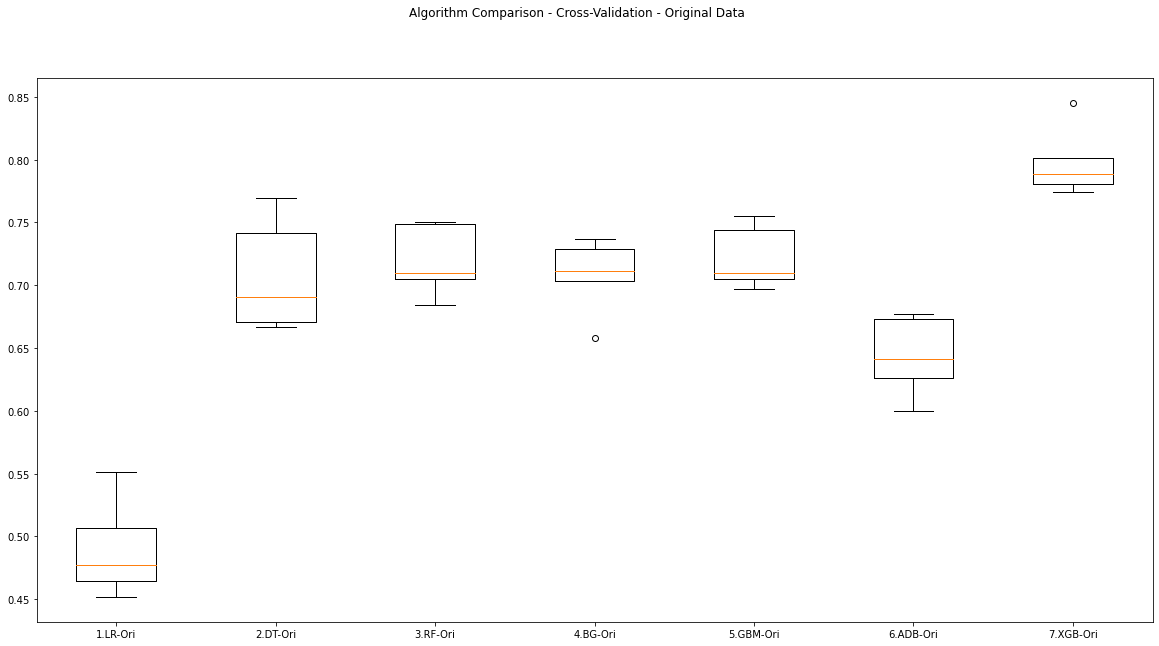

<IPython.core.display.Javascript object>

In [29]:
# Plotting boxplots for CV scores of all models defined above

fig = plt.figure(figsize=(20, 10))

fig.suptitle("Algorithm Comparison - Cross-Validation - Original Data")
ax = fig.add_subplot(111)

plt.boxplot(results_ori)
ax.set_xticklabels(names_ori)

plt.show()

#### Jonathan's Comments:

* Top 3 Cross-Validation Performance:

    1. Xgboost with 79.2 %
    2. Gradient Boosting with 72.2 %
    3. Random Forest with 71.9%
    
    
* Seems the models generalized well the data

* Performance on Validation set is quite poor  
    

### Model Building with Oversampled data


In [30]:
print(
    "Before Oversampling, counts of label '1 (Failures)': {}".format(sum(y_train == 1))
)
print(
    "Before Oversampling, counts of label '0 (No failures)': {} \n".format(
        sum(y_train == 0)
    )
)

Before Oversampling, counts of label '1 (Failures)': 777
Before Oversampling, counts of label '0 (No failures)': 13223 



<IPython.core.display.Javascript object>

In [31]:
# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

<IPython.core.display.Javascript object>

In [32]:
print(
    "After Oversampling, counts of label '1 (Failures)': {}".format(
        sum(y_train_over == 1)
    )
)
print(
    "After Oversampling, counts of label '0 (No failures)': {} \n".format(
        sum(y_train_over == 0)
    )
)

After Oversampling, counts of label '1 (Failures)': 13223
After Oversampling, counts of label '0 (No failures)': 13223 



<IPython.core.display.Javascript object>

#### Jonathan's Comments:

Using SMOTE the imbalance issue has been treated, now we have the same number of rows for both classes

Nomenclature for this step:
    
    - LR-Over for Logistic Regression model with Original Data
    - DT-Over for Decision Tree model with Original Data
    - RF-Over for Random Forest with Original Data
    - BG-Over for Bagging with Original Data
    - ADB-Over for Adaboost with Original Data
    - XFG-Over for XG-Boost with Original Data

In [33]:
%%time
models_over = []  # Empty list to store all the models. Better to use a dictionnary for this...

# Appending models into the list
models_over.append(("1.LR-Over", LogisticRegression(solver="newton-cg", random_state=1)))
models_over.append(("2.DT-Over", DecisionTreeClassifier(random_state=1)))
models_over.append(("3.RF-Over", RandomForestClassifier(random_state=1)))
models_over.append(("4.BG-Over", BaggingClassifier(random_state=1)))
models_over.append(("5.GBM-Over", GradientBoostingClassifier(random_state=1)))
models_over.append(("6.ADB-Over", AdaBoostClassifier(random_state=1)))
models_over.append(("7.XGB-Over", XGBClassifier(random_state=1, eval_metric="logloss", use_label_encoder=False)))


results_over = []  # Empty list to store all model's CV scores
names_over = []  # Empty list to store name of the models

# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Training Performance:" "\n")

kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5

for name, model in models_over:
    scoring = "recall"
    
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over, scoring=scoring, cv=kfold
    )
    results_over.append(cv_result)
    names_over.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Validation Performance:" "\n")

for name, model in models_over:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val)) * 100
    print("{}: {}".format(name, scores))


Cross-Validation Training Performance:

1.LR-Over: 89.17800548518741
2.DT-Over: 97.0128321355339
3.RF-Over: 98.29090368319754
4.BG-Over: 97.5119441528989
5.GBM-Over: 93.29201902370527
6.ADB-Over: 90.4787470436327
7.XGB-Over: 98.95639018614746

Validation Performance:

1.LR-Over: 84.98498498498499
2.DT-Over: 78.37837837837837
3.RF-Over: 85.58558558558559
4.BG-Over: 82.58258258258259
5.GBM-Over: 87.68768768768768
6.ADB-Over: 86.18618618618619
7.XGB-Over: 85.58558558558559
CPU times: total: 6min 43s
Wall time: 4min 19s


<IPython.core.display.Javascript object>

#### Jonathan's Comments:

* Some models as Decision Tree, Random Forest, Bagging and XGBoost are overffiting
    

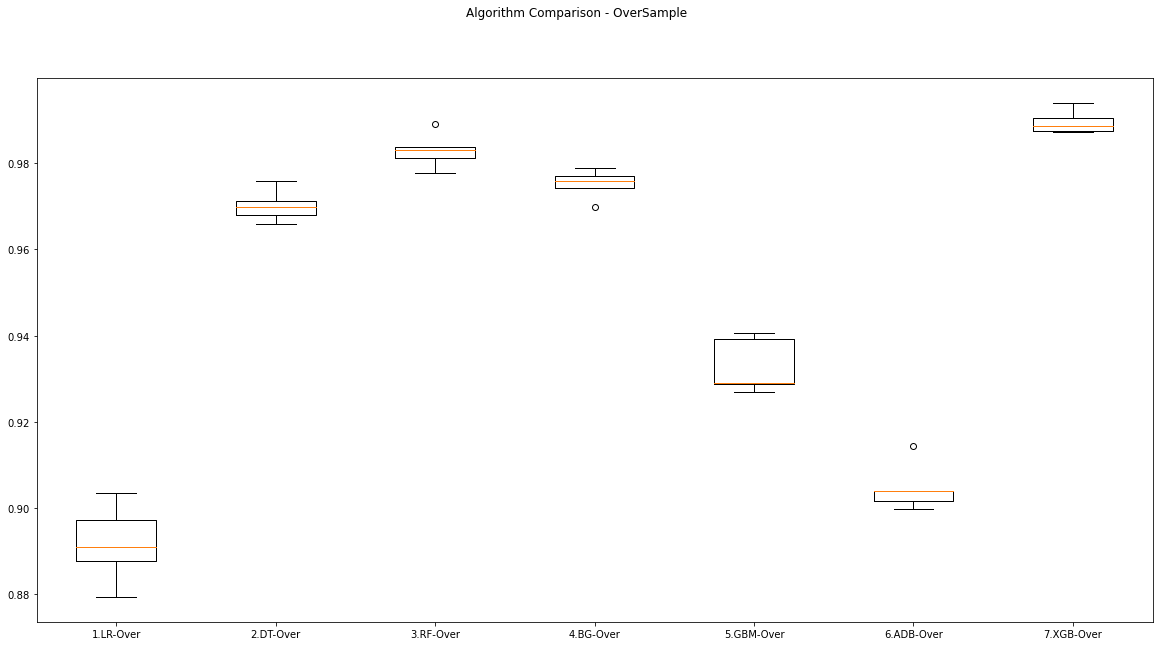

<IPython.core.display.Javascript object>

In [34]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(20, 10))

fig.suptitle("Algorithm Comparison - OverSample")
ax = fig.add_subplot(111)

plt.boxplot(results_over)
ax.set_xticklabels(names_over)

plt.show()

### Model Building with Undersampled data

In [35]:
print(
    "Before Oversampling, counts of label '1 (Failures)': {}".format(sum(y_train == 1))
)
print(
    "Before Oversampling, counts of label '0 (No failures)': {} \n".format(
        sum(y_train == 0)
    )
)

Before Oversampling, counts of label '1 (Failures)': 777
Before Oversampling, counts of label '0 (No failures)': 13223 



<IPython.core.display.Javascript object>

In [36]:
# Random undersampler for under sampling the data
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

<IPython.core.display.Javascript object>

In [37]:
print(
    "After Undersampling, counts of label '1 (Failures)': {}".format(
        sum(y_train_un == 1)
    )
)
print(
    "After Undersampling, counts of label '0 (No failures)': {} \n".format(
        sum(y_train_un == 0)
    )
)

After Undersampling, counts of label '1 (Failures)': 777
After Undersampling, counts of label '0 (No failures)': 777 



<IPython.core.display.Javascript object>

#### Jonathan's Comments:

Using The random sampler  the imbalance issue has been treated, now we have the same number of rows for both classes

Nomenclature for this step:
    
    - LR-Under for Logistic Regression model with Under Sampled Data
    - DT-Under for Decision Tree model with Under Sampled Data
    - RF-Under for Random Forest with Under Sampled Data
    - BG-Under for Bagging with Under Sampled Data
    - ADB-Under for Adaboost with Under Sampled Data
    - XFG-Under for XG-Boost with Under Sampled Data

In [38]:
%%time
models_under = []  # Empty list to store all the models. Better to use a dictionnary for this...

# Appending models into the list
models_under.append(("1.LR-Under", LogisticRegression(solver="newton-cg", random_state=1)))
models_under.append(("2.DT-Under", DecisionTreeClassifier(random_state=1)))
models_under.append(("3.RF-Under", RandomForestClassifier(random_state=1)))
models_under.append(("4.BG-Under", BaggingClassifier(random_state=1)))
models_under.append(("5.GBM-Under", GradientBoostingClassifier(random_state=1)))
models_under.append(("6.ADB-Under", AdaBoostClassifier(random_state=1)))
models_under.append(("7.XGB-Under", XGBClassifier(random_state=1, eval_metric="logloss", use_label_encoder=False)))

results_under = []  # Empty list to store all model's CV scores
names_under = []  # Empty list to store name of the models

# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Training Performance:" "\n")

kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5

for name, model in models_under:
    scoring = "recall"
    
    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un, scoring=scoring, cv=kfold
    )
    results_under.append(cv_result)
    names_under.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

   
print("\n" "Validation Performance:" "\n")

for name, model in models_under:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val)) * 100
    print("{}: {}".format(name, scores))


Cross-Validation Training Performance:

1.LR-Under: 87.26220016542598
2.DT-Under: 86.22167080231597
3.RF-Under: 90.34822167080232
4.BG-Under: 88.0339123242349
5.GBM-Under: 89.32009925558313
6.ADB-Under: 87.25971877584782
7.XGB-Under: 89.70554177005789

Validation Performance:

1.LR-Under: 84.68468468468468
2.DT-Under: 84.08408408408408
3.RF-Under: 88.28828828828829
4.BG-Under: 87.08708708708708
5.GBM-Under: 88.28828828828829
6.ADB-Under: 85.88588588588588
7.XGB-Under: 89.1891891891892
CPU times: total: 21.7 s
Wall time: 11.4 s


<IPython.core.display.Javascript object>

#### Jonathan's Comments:

* Seems the models generalized well the data
* The validation performance is good better than models with original data 

    

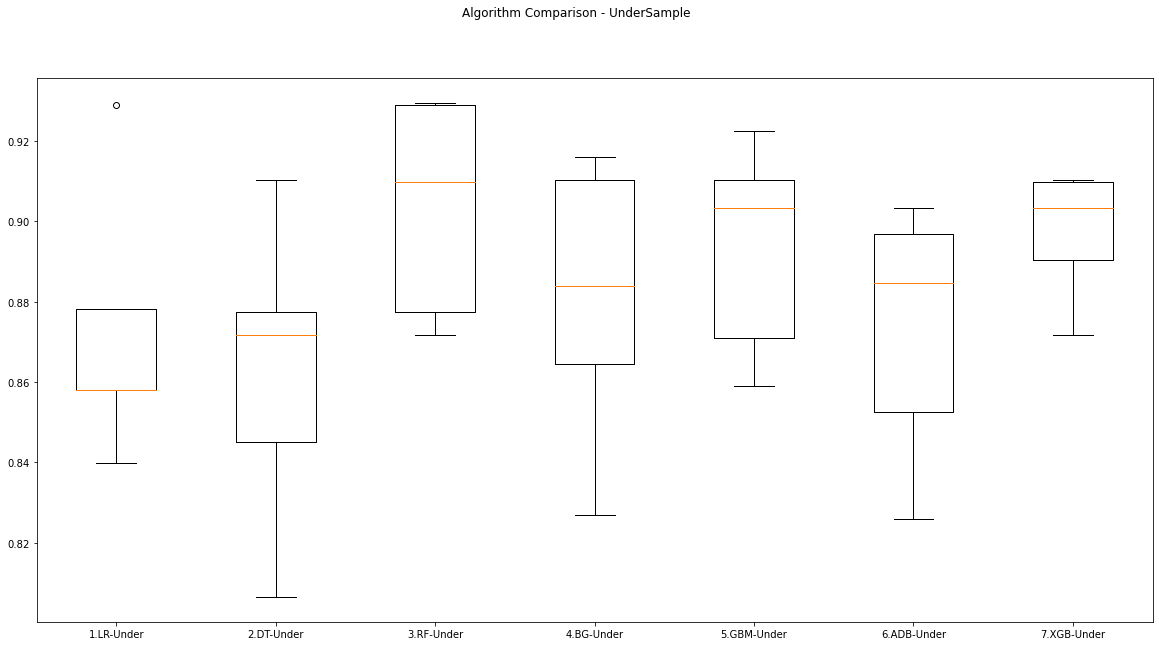

<IPython.core.display.Javascript object>

In [39]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(20, 10))

fig.suptitle("Algorithm Comparison - UnderSample")
ax = fig.add_subplot(111)

plt.boxplot(results_under)
ax.set_xticklabels(names_under)

plt.show()

## Model Selection

#### Jonathan's Comments:

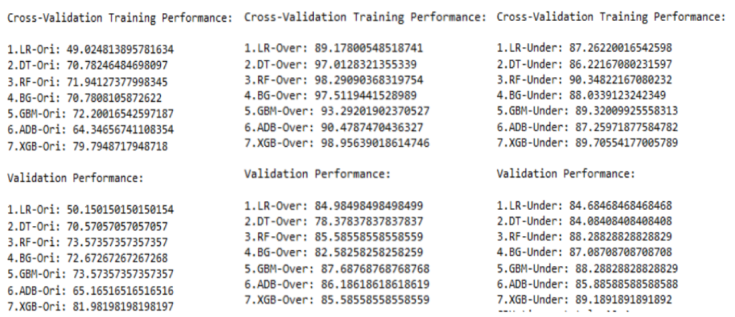

As is shown on the picture above we have good scores on over and under sampled datasets for cross-validation training but I think that is not good idea tune a overfitted model, so the criteria that I want to use to choose the models to tune the hyperparamerts will be the best score on Validations set, the models choosed are:

    - XGBoost with Under Sampled data
    - Gradient Boosting with Under Sampled data
    - Bagging with Under Sampled data
    - Since Bagging and Random Forest both have the same score let's choose Randon Forest with Undersample data in order       to do hyperparameter tuning

## HyperparameterTuning 

### Sample Parameter Grids

**Hyperparameter tuning can take a long time to run, so to avoid that time complexity - you can use the following grids, wherever required.**

- For Gradient Boosting:

param_grid = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7], 
    "max_features":[0.5,0.7]
}

- For Adaboost:

param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "base_estimator": [DecisionTreeClassifier(max_depth=1, random_state=1), DecisionTreeClassifier(max_depth=2, random_state=1), DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

- For Bagging Classifier:

param_grid = {
    'max_samples': [0.8,0.9,1], 
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}

- For Random Forest:

param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

- For Decision Trees:

param_grid = {
    'max_depth': np.arange(2,6), 
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}

- For Logistic Regression:

param_grid = {'C': np.arange(0.1,1.1,0.1)}

- For XGBoost:

param_grid={
    'n_estimators': [150, 200, 250],
    'scale_pos_weight': [5,10],
    'learning_rate': [0.1,0.2],
    'gamma': [0,3,5],
    'subsample': [0.8,0.9]
}

### Tuning method for XGBoost with Undersampled data

In [58]:
# defining model
model = XGBClassifier(random_state=1, eval_metric="logloss", use_label_encoder=False)

# Parameter grid to pass in RandomSearchCV

param_grid = {
    "n_estimators": [50, 100, 150],
    "scale_pos_weight": [5, 10],
    "learning_rate": [0.1, 0.2],
    "gamma": [0, 3, 5],
    "subsample": [0.7, 0.8, 0.9],
}

scorer = metrics.make_scorer(metrics.recall_score)

# Calling RandomizedSearchCV
xgb_tuned2 = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=10,
    n_jobs=-1,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# Fitting parameters in RandomizedSearchCV
xgb_tuned2.fit(X_train_un, y_train_un)

print(
    "Best parameters are {} with CV score={}:".format(
        xgb_tuned2.best_params_, xgb_tuned2.best_score_
    )
)

Best parameters are {'subsample': 0.8, 'scale_pos_weight': 10, 'n_estimators': 150, 'learning_rate': 0.1, 'gamma': 5} with CV score=0.9291976840363937:


<IPython.core.display.Javascript object>

#### Let's run the model with hyperparameters obtained

In [59]:
xgb_tuned2 = xgb_tuned2.best_estimator_

<IPython.core.display.Javascript object>

In [60]:
# Calculating different metrics on train set
xgboost_random_train = model_performance_classification_sklearn(
    xgb_tuned2, X_train_un, y_train_un
)
print("Training performance:")
xgboost_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.991,1.000,0.982,0.991


<IPython.core.display.Javascript object>

In [61]:
# Calculating different metrics on validation set
xgboost_random_val = model_performance_classification_sklearn(xgb_tuned2, X_val, y_val)
print("Validation performance:")
xgboost_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.863,0.904,0.276,0.423


<IPython.core.display.Javascript object>

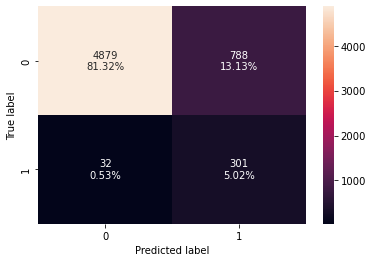

<IPython.core.display.Javascript object>

In [62]:
# creating confusion matrix
confusion_matrix_sklearn(xgb_tuned2, X_val, y_val)

#### Jonathan's Comments:

* We can see that performance is too bad since the confusion matrix is showing a model that is not able to generalize the data

* Let's check what happens with other models and the tuning process

### Sample tuning method for Gradient Boost with Undersampled data

In [72]:
# defining model
model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "max_depth": [10, 100, 250, 25],
    "learning_rate": [0.2, 0.05, 1],
    "subsample": [0.5, 0.7],
    "max_features": [0.5, 0.7, 0.9],
}

scorer = metrics.make_scorer(metrics.recall_score)

# Calling RandomizedSearchCV
gbc_tuned = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=10,
    n_jobs=-1,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# Fitting parameters in RandomizedSearchCV
gbc_tuned.fit(X_train_un, y_train_un)

print(
    "Best parameters are {} with CV score={}:".format(
        gbc_tuned.best_params_, gbc_tuned.best_score_
    )
)

Best parameters are {'subsample': 0.7, 'max_features': 0.7, 'max_depth': 250, 'learning_rate': 0.05} with CV score=0.9073200992555831:


<IPython.core.display.Javascript object>

#### Let's run the model with hyperparameters obtained

In [73]:
gbc_tuned = gbc_tuned.best_estimator_

<IPython.core.display.Javascript object>

In [74]:
# Calculating different metrics on train set
gbc_tuned_random_train = model_performance_classification_sklearn(
    gbc_tuned, X_train_un, y_train_un
)
print("Training performance:")
gbc_tuned_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,1.000,1.000,1.000,1.000


<IPython.core.display.Javascript object>

In [75]:
# Calculating different metrics on validation set
gbc_tuned_random_val = model_performance_classification_sklearn(gbc_tuned, X_val, y_val)
print("Validation performance:")
gbc_tuned_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.933,0.886,0.450,0.597


<IPython.core.display.Javascript object>

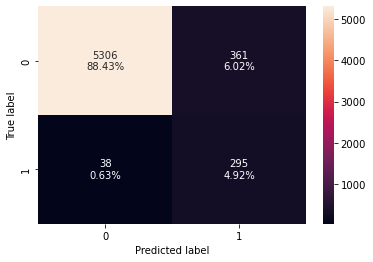

<IPython.core.display.Javascript object>

In [76]:
# creating confusion matrix
confusion_matrix_sklearn(gbc_tuned, X_val, y_val)

#### Jonathan's Comments:

* After of tune the Gradient Boost model  with Undersampled data we can see that is overfitting since all scores on training data reach 100 % meanwhile the scores on validation dropped 

### Sample tuning method for Bagging with Undersampled data

In [77]:
%%time
# defining model
model = BaggingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = { 'max_samples': [0.8,0.9,1], 
               'max_features': [0.7,0.8,0.9],
               'n_estimators' : [30,50,70], }

scorer = metrics.make_scorer(metrics.recall_score)
# Calling RandomizedSearchCV
bagging_estimator_tuned = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=10,
    n_jobs=-1,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# Fitting parameters in RandomizedSearchCV
bagging_estimator_tuned.fit(X_train_un, y_train_un)

print("Best parameters are {} with CV score={}:".format(bagging_estimator_tuned.best_params_, bagging_estimator_tuned.best_score_))

Best parameters are {'n_estimators': 70, 'max_samples': 0.8, 'max_features': 0.7} with CV score=0.9008684863523573:
CPU times: total: 1.09 s
Wall time: 4.48 s


<IPython.core.display.Javascript object>

#### Let's run the model with hyperparameters obtained

In [78]:
bagging_estimator_tuned = bagging_estimator_tuned.best_estimator_

<IPython.core.display.Javascript object>

In [79]:
# Calculating different metrics on train set
bagging_estimator_tuned_random_train = model_performance_classification_sklearn(
    bagging_estimator_tuned, X_train_un, y_train_un
)
print("Training performance:")
bagging_estimator_tuned_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.999,0.997,1.000,0.999


<IPython.core.display.Javascript object>

In [80]:
# Calculating different metrics on validation set
bagging_estimator_tuned_random_val = model_performance_classification_sklearn(
    bagging_estimator_tuned, X_val, y_val
)
print("Validation performance:")
bagging_estimator_tuned_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.937,0.874,0.463,0.605


<IPython.core.display.Javascript object>

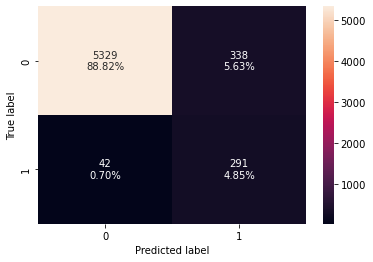

<IPython.core.display.Javascript object>

In [82]:
# creating confusion matrix
confusion_matrix_sklearn(bagging_estimator_tuned, X_val, y_val)

### Sample tuning method for Random Forest with Undersampled data

In [83]:
%%time
# defining model
model = RandomForestClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = { "n_estimators": [200,250,300], 
               "min_samples_leaf": np.arange(1, 4), 
               "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'], 
               "max_samples": np.arange(0.4, 0.7, 0.1) }
# Calling RandomizedSearchCV
rf_tuned = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=10,
    n_jobs=-1,
    scoring=scorer,
    cv=5,
    random_state=1,
)
# Fitting parameters in RandomizedSearchCV
rf_tuned.fit(X_train_un, y_train_un)

print("Best parameters are {} with CV score={}:".format(rf_tuned.best_params_, rf_tuned.best_score_))

Best parameters are {'n_estimators': 300, 'min_samples_leaf': 1, 'max_samples': 0.6, 'max_features': 'sqrt'} with CV score=0.9047477253928868:
CPU times: total: 984 ms
Wall time: 3.65 s


<IPython.core.display.Javascript object>

#### Let's run the model with hyperparameters obtained

In [84]:
rf_tuned = rf_tuned.best_estimator_

<IPython.core.display.Javascript object>

In [85]:
# Calculating different metrics on train set
rf_tuned_random_train = model_performance_classification_sklearn(
    rf_tuned, X_train_un, y_train_un
)
print("Training performance:")
rf_tuned_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.988,0.978,0.999,0.988


<IPython.core.display.Javascript object>

In [86]:
# Calculating different metrics on validation set
rf_tuned_random_val = model_performance_classification_sklearn(rf_tuned, X_val, y_val)
print("Validation performance:")
rf_tuned_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.934,0.880,0.451,0.597


<IPython.core.display.Javascript object>

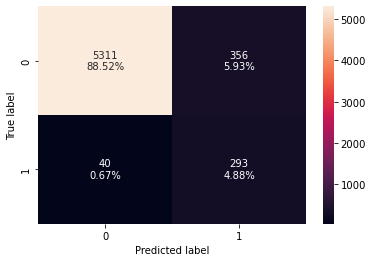

<IPython.core.display.Javascript object>

In [87]:
# creating confusion matrix
confusion_matrix_sklearn(rf_tuned, X_val, y_val)

## Model performance comparison and choosing the final model

In [91]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        xgboost_random_val.T,
        gbc_tuned_random_val.T,
        bagging_estimator_tuned_random_val.T,
        rf_tuned_random_val.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "XGBoost Under Sampled Tuned",
    "GB Under Sampled Tuned",
    "Bagging Under Sampled Tuned",
    "Random Forest Under Sampled Tuned",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,XGBoost Under Sampled Tuned,GB Under Sampled Tuned,Bagging Under Sampled Tuned,Random Forest Under Sampled Tuned
Accuracy,0.863,0.933,0.937,0.934
Recall,0.904,0.886,0.874,0.880
Precision,0.276,0.450,0.463,0.451
F1,0.423,0.597,0.605,0.597


<IPython.core.display.Javascript object>

#### Jonathan's Comment

The final set choosed that have the best Recall is XGBoost Under Sampled Tuned with a 90.4% performance

### Test set final performance

#### Jonathan's Comments

 I have let the test dataset treatment for this moment so let's execute the test data processing

In [93]:
# Loading the test dataset
test = pd.read_csv("test.csv")

<IPython.core.display.Javascript object>

In [94]:
X_test = test.drop(["Target"], axis=1)
y_test = test["Target"]

print(X_test.shape)

(5000, 40)


<IPython.core.display.Javascript object>

Let's impute as was done with Training and validation sets

In [95]:
imputer_test = SimpleImputer(strategy="median")

<IPython.core.display.Javascript object>

In [96]:
X_test = pd.DataFrame(imputer.fit_transform(X_test), columns=X_test.columns)

<IPython.core.display.Javascript object>

In [98]:
xg_under_test = model_performance_classification_sklearn(xgb_tuned2, X_test, y_test)
print("Test performance:")
xg_under_test

Test performance:


,Accuracy,Recall,Precision,F1
0,0.857,0.894,0.268,0.413


<IPython.core.display.Javascript object>

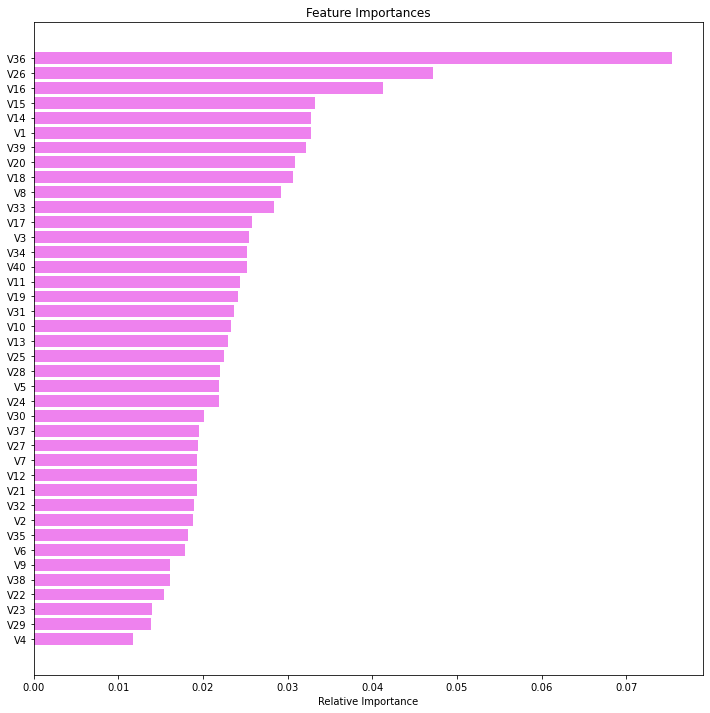

<IPython.core.display.Javascript object>

In [116]:
feature_names = X.columns
importances = xgb_tuned2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Pipelines to build the final model


In [107]:
# splitting data in finals dataset
X_test_final = test.drop(["Target"], axis=1)
y_test_final = test["Target"]

<IPython.core.display.Javascript object>

In [105]:
# Data imputation
imputer = SimpleImputer(strategy="median")

<IPython.core.display.Javascript object>

In [108]:
# As the model used works with undersample dataset is needed do it

rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train_final, y_train_final)

<IPython.core.display.Javascript object>

### Jonathan's Comments

Using the model choosed with the hyperparameters found

In [109]:
xg_model = XGBClassifier(
    subsample=0.8, scale_pos_weight=10, n_estimators=150, learning_rate=0.1, gamma=5
)

<IPython.core.display.Javascript object>

Pipeline using the steps done before

In [113]:
final_model = Pipeline(steps=[("imputer", imputer), ("XGBoost", xg_model)])

final_model.fit(X_train_un, y_train_un)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('XGBoost',
                 XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
                               colsample_bylevel=1, colsample_bynode=1,
                               colsample_bytree=1, early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               gamma=5, gpu_id=-1, grow_policy='depthwise',
                               importance_type=None, interaction_constraints='',
                               learning_rate=0.1, max_bin=256,
                               max_cat_to_onehot=4, max_delta_step=0,
                               max_depth=6, max_leaves=0, min_child_weight=1,
                               missing=nan, monotone_constraints='()',
                               n_estimators=150, n_jobs=0, num_parallel_tree=1,
                               predictor='auto', random_state=0, reg_alpha=0,
                               reg_lambda=1, ...))])

<IPython.core.display.Javascript object>

In [115]:
final_model_train = model_performance_classification_sklearn(
    final_model, X_test_final, y_test_final
)
final_model_train

,Accuracy,Recall,Precision,F1
0,0.857,0.894,0.270,0.414


<IPython.core.display.Javascript object>

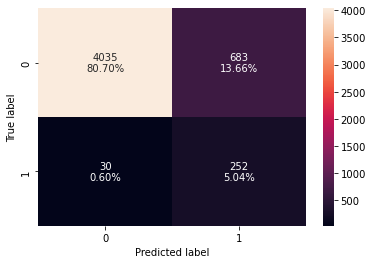

<IPython.core.display.Javascript object>

In [117]:
confusion_matrix_sklearn(final_model, X_test_final, y_test_final)

# Business Insights and Conclusions

- The model give us the next numbers:

    * 5.04% of failures are correctly predicted by the model (TP)
    * 0.60% of real failures were not detected by the model (FN)
    * In 80.70% model predicted no failures and actually also its not a failure.
    * 13.66% are detections where there is no failure
            
- The best model found was the XGBoost using undersampled data, that give us a recall of 89.4%

- The false negative rate is about 0.60%, one objective was reduce the False negative and this is a good number 

- The top 5 of most important features are V36,V26,V16,V15, V14  but we don't have description of these.

- Have the features without description don't allow to have a whole picture of the problem, if we can know what means each feature we could understand the relation between them and perform best tuning.

- To give better insights and conclusions is needed to review this exercise with a "expert" in order he/she can explain us for example what is the description of each sensor, in this way we can explain better the predictions given by the model 
